# U-Net–DenseNet201 Oil Spill Segmentation Using Sentinel-1 SAR

### VV + VH Dual-Polarization Deep Learning Experiment

This notebook trains and evaluates a U-Net segmentation model with a
DenseNet201 encoder for oil spill detection using Sentinel-1 SAR imagery.

The model uses two SAR channels:

- **VV polarization**
- **VH polarization**

The segmentation problem is formulated as binary classification:

- **0 — Background / non-oil**
- **1 — Oil spill**

The notebook includes:

- Sentinel-1 SAR data loading and preprocessing
- Data augmentation
- U-Net with DenseNet201 encoder
- 5-fold cross-validation
- IoU and F1 evaluation
- False Alarm Rate (FAR)
- Expected Calibration Error (ECE)
- Reliability diagrams
- MC Dropout uncertainty estimation
- Independent holdout testing
- Look-alike false-positive analysis

> **Important:** Training, fine-tuning, and holdout evaluation are separate
> stages. The independent test set must not be used for model training or
> model selection.

# 1. Environment Setup

This section installs the required Python packages and verifies that
PyTorch can access the GPU.

> **Recommended environment:** Google Colab with GPU runtime.

The main dependencies are:

- PyTorch
- torchvision
- segmentation-models-pytorch
- Rasterio
- OpenCV
- NumPy
- Matplotlib
- scikit-learn

In [1]:
!pip -q install scikit-learn
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install rasterio albumentations==1.4.7 opencv-python matplotlib tqdm lightning==2.3.3
!pip -q install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.5/808.5 kB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.2 MB/s eta 0:00:00


In [2]:
#@title ⛏️ Setup


import os, sys, math, time, json, random, pathlib
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision.transforms.functional import normalize as tv_normalize
import rasterio
import cv2
import csv
from datetime import datetime

from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast

print('Torch:', torch.__version__, 'CUDA:', torch.cuda.is_available())

Torch: 2.11.0+cu128 CUDA: True


## 1.2 Mount Google Drive

The dataset, trained checkpoints, and experiment logs are stored in
Google Drive.

Running this cell reconnects the notebook to the configured Drive folders.

In [3]:
#@title 🔗 Mount Google Drive
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


# 2. Experiment Configuration

This section defines all paths and major experiment hyperparameters.

The configuration contains:

- training dataset folders
- independent holdout test folders
- checkpoint/output directory
- number of classes
- number of epochs
- batch size
- learning rate
- weight decay
- input crop size
- K-fold configuration
- calibration bins
- experiment logging

Changing experiment parameters here avoids modifying the training loop.

### Main Training Parameters

Current configuration:

| Parameter | Value |
|---|---:|
| Classes | 2 |
| Epochs | 50 |
| Batch size | 8 |
| Learning rate | 5e-4 |
| Weight decay | 1e-4 |
| Crop size | 512 × 512 |
| K-folds | 5 |
| ECE bins | 10 |
| AMP | Enabled |

The two output classes correspond to background and oil spill pixels.

In [4]:
from dataclasses import dataclass, field


@dataclass
class Cfg:
    drive_root: str = '/content/drive/MyDrive'
    data_dir: str = '/content/drive/MyDrive/Sentinel SAR datasets'

    # --- TRAINING SET FOLDERS ---
    oil_img_dir: str       = 'Oil'
    oil_mask_dir: str      = 'Mask_oil'
    no_oil_img_dir: str    = 'No_oil'
    no_oil_mask_dir: str   = 'Mask_no_oil'
    look_img_dir: str      = 'Lookalike'
    look_mask_dir: str     = 'Mask_lookalike'

    # --- HOLDOUT TEST SET (optional, not used in K-fold yet) ---
    test_img_dir: str  = '02_Test_images_and_ground_truth/Images'
    test_mask_dir: str = '02_Test_images_and_ground_truth/Mask'

     # --- HOLDOUT TEST SET (optional, not used in K-fold yet) ---
    test_oil_img_dir: str  = '02_Test_images_and_ground_truth/Images/Oil'
    test_oil_mask_dir: str = '02_Test_images_and_ground_truth/Mask/Oil'
    test_no_oil_img_dir: str  = '02_Test_images_and_ground_truth/Images/No oil'
    test_no_oil_mask_dir: str = '02_Test_images_and_ground_truth/Mask/No oil'
    test_look_img_dir: str  = '02_Test_images_and_ground_truth/Images/Lookalike'
    test_look_mask_dir: str = '02_Test_images_and_ground_truth/Mask/Lookalike'

    out_dir: str = '/content/drive/MyDrive/oil_spill_checkpoints/periments/unet2ch'






    num_classes: int = 2  # background, oil
    epochs: int = 50
    batch_size: int = 8
    lr: float = 5e-4
    weight_decay: float = 1e-4
    crop_size: int = 512
    amp: bool = True
    seed: int = 1337

    # --- K-FOLD / CALIBRATION SETTINGS ---
    k_folds: int = 5
    n_bins: int = 10      # reliability bins for ECE


    log_file: str = field(init=False)

    # This method runs *after* the instance (cfg) is created
    def __post_init__(self):
        # 1. Define the full path for the log file
        self.log_file = os.path.join(self.out_dir, "unet_densenet201_new_training_log.csv")


        # 2. Ensure the output directory exists
        os.makedirs(self.out_dir, exist_ok=True)

        # 3. Write headers only if the file doesn't exist
        if not os.path.isfile(self.log_file):
            print(f"Creating new log file: {self.log_file}")
            with open(self.log_file, mode="w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow([
                    "timestamp", "fold", "epoch", "train_loss",
                    "val_loss", "IoU", "F1", "FAR", "ECE", "uncertainty_var", "test_iou", "test_f1"
                ])

cfg = Cfg()
os.makedirs(cfg.out_dir, exist_ok=True)


# 3. Dataset Preparation

The dataset contains three scene categories:

### Oil
SAR images containing annotated oil spills.

### No Oil
SAR images representing normal ocean/background conditions.

### Look-Alike
SAR scenes containing phenomena that may produce dark signatures similar
to oil spills but are not labelled as oil.

Image files are paired with their corresponding segmentation masks before
being passed to the PyTorch Dataset class.

In [5]:
from typing import List, Dict

def build_training_items(cfg: Cfg) -> List[Dict]:
    """Collect all (image, mask) pairs from Oil, No_oil, Lookalike."""
    items = []

    def add_pairs(img_subdir, mask_subdir, label):
        img_dir = os.path.join(cfg.data_dir, img_subdir)
        mask_dir = os.path.join(cfg.data_dir, mask_subdir)
        assert os.path.isdir(img_dir), f"Missing folder: {img_dir}"
        assert os.path.isdir(mask_dir), f"Missing folder: {mask_dir}"

        for name in sorted(os.listdir(img_dir)):
            if not name.lower().endswith('.tif'):
                continue
            img_path = os.path.join(img_dir, name)
            base = os.path.splitext(name)[0]
            if img_subdir in (cfg.test_oil_img_dir, cfg.test_no_oil_img_dir, cfg.test_look_img_dir):
              base = base + '_segmentation'
            # mask can be .png or .tif
            mask_png = os.path.join(mask_dir, base + '.png')
            mask_tif = os.path.join(mask_dir, base + '.tif')
            if os.path.exists(mask_png):
                mask_path = mask_png
            elif os.path.exists(mask_tif):
                mask_path = mask_tif
            else:
                print(f"[WARN] No mask found for {img_path}")
                continue

            items.append({
                'img': img_path,
                'mask': mask_path,
                'subset': label,
                'name': name,
            })

    add_pairs(cfg.oil_img_dir,     cfg.oil_mask_dir,     'oil')
    add_pairs(cfg.no_oil_img_dir,  cfg.no_oil_mask_dir,  'no_oil')
    add_pairs(cfg.look_img_dir,    cfg.look_mask_dir,    'lookalike')


    # DO NOT INCLUDE THIS DURING TRAINING
    #add_pairs(cfg.test_oil_img_dir,   cfg.test_oil_mask_dir,    'test_oil')
    #add_pairs(cfg.test_no_oil_img_dir,   cfg.test_no_oil_mask_dir,    'test_no_oil')
    #add_pairs(cfg.test_look_img_dir,   cfg.test_look_mask_dir,    'test_look')

    print(f"Total training items: {len(items)} "
          f"(oil={sum(i['subset']=='oil' for i in items)}, "
          f"no_oil={sum(i['subset']=='no_oil' for i in items)}, "
          f"lookalike={sum(i['subset']=='lookalike' for i in items)})")
    return items

all_items = build_training_items(cfg)


Total training items: 2389 (oil=1200, no_oil=685, lookalike=504)


In [6]:
# ============================================================
# SAFETY CHECK: HOLDOUT TEST DATA MUST NOT BE IN all_items
# ============================================================

training_subsets = {item['subset'] for item in all_items}

print("Subsets found in all_items:", training_subsets)

for forbidden_subset in ('test_oil', 'test_no_oil', 'test_look'):
    assert forbidden_subset not in training_subsets, (
        f"DATA LEAKAGE DETECTED: {forbidden_subset} found in all_items!"
    )

print("✅ PASS: Independent holdout test data are NOT in all_items.")

Subsets found in all_items: {'lookalike', 'no_oil', 'oil'}
✅ PASS: Independent holdout test data are NOT in all_items.


## 3.2 PyTorch Dataset

`OilSpillDataset` performs the following operations:

1. Loads Sentinel-1 TIFF images.
2. Extracts the first two channels as VV and VH.
3. Loads the corresponding binary segmentation mask.
4. Converts the mask to background/oil classes.
5. Applies SAR intensity clipping and normalization.
6. Applies augmentation during training.
7. Performs random 512 × 512 cropping when enabled.
8. Converts the arrays to PyTorch tensors.

For holdout evaluation, cropping and augmentation should be disabled so
that the full image is evaluated.

### Data Augmentation

Augmentation is applied only during model training.

Current augmentation operations include:

- Random horizontal flipping
- Random vertical flipping
- Random 90°, 180°, or 270° rotation
- Small Gaussian perturbations
- Mild contrast and brightness variation

The same geometric transformations are applied to both the SAR image
and its segmentation mask.

No augmentation is applied to validation or holdout test images.

In [8]:
class OilSpillDataset(Dataset):
    def __init__(self, items, crop_size=512, augment=True):
        """
        items: list of dicts with keys ['img', 'mask', 'subset', 'name']
        """
        self.items = items
        self.crop = crop_size
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def _read_tiff_2ch(self, path):
        with rasterio.open(path) as ds:
            arr = ds.read()  # (C,H,W) or (H,W)
        # Force to 2 bands [VV, VH]
        if arr.ndim == 3 and arr.shape[0] >= 2:
            arr = arr[:2]
        elif arr.ndim == 3 and arr.shape[0] == 1:
            arr = np.concatenate([arr, arr], 0)
        elif arr.ndim == 2:
            arr = np.stack([arr, arr], 0)
        else:
            raise ValueError(f"Unexpected TIFF shape {arr.shape} for {path}")
        arr = np.transpose(arr, (1,2,0)).astype(np.float32)  # (H,W,2)
        return arr

    def _read_mask(self, path):
        if path.lower().endswith('.tif') or path.lower().endswith('.tiff'):
            with rasterio.open(path) as ds:
                m = ds.read(1)
        else:
            m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        m = (m > 0).astype(np.uint8)   # binary 0/1
        return m

    def _random_crop(self, img, mask, size):
        H,W,_ = img.shape
        if H < size or W < size:
            pad_h, pad_w = max(0, size-H), max(0, size-W)
            img  = cv2.copyMakeBorder(img,  0, pad_h, 0, pad_w, cv2.BORDER_REFLECT_101)
            mask = cv2.copyMakeBorder(mask, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)
            H,W,_ = img.shape
        y = random.randint(0, H-size)
        x = random.randint(0, W-size)
        return img[y:y+size, x:x+size], mask[y:y+size, x:x+size]

    '''def _augs(self, img, mask):
        # only for training
        if self.augment:
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.fliplr(img))
                mask = np.ascontiguousarray(np.fliplr(mask))
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.flipud(img))
                mask = np.ascontiguousarray(np.flipud(mask))
        return img, mask'''

    def _augs(self, img, mask):
        if self.augment:
            # Horizontal flip
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.fliplr(img))
                mask = np.ascontiguousarray(np.fliplr(mask))

            # Vertical flip
            if random.random() < 0.5:
                img  = np.ascontiguousarray(np.flipud(img))
                mask = np.ascontiguousarray(np.flipud(mask))

            # 90-degree rotations (0,90,180,270)
            if random.random() < 0.5:
                k = random.choice([1, 2, 3])  # 90,180,270
                img  = np.ascontiguousarray(np.rot90(img,  k, axes=(0,1)))
                mask = np.ascontiguousarray(np.rot90(mask, k, axes=(0,1)))

            # Small Gaussian noise (SAR-like speckle)
            if random.random() < 0.3:
                noise = np.random.normal(0, 0.05, img.shape).astype(np.float32)
                img = img + noise
                img = np.clip(img, -5.0, 5.0)  # keep in a reasonable range

            # Slight contrast/brightness jitter
            if random.random() < 0.3:
                alpha = 1.0 + 0.2 * (2*random.random() - 1)  # 0.8–1.2
                beta  = 0.1 * (2*random.random() - 1)        # -0.1–0.1
                img = alpha * img + beta
        return img, mask

    def __getitem__(self, idx):
        item = self.items[idx]
        img_path  = item['img']
        mask_path = item['mask']

        img  = self._read_tiff_2ch(img_path)
        mask = self._read_mask(mask_path)

        # normalize each channel (same as your training code)
        img = np.clip(img, -50, 5)
        img = (img - (-22.5)) / 12.5

        img, mask = self._augs(img, mask)
        if self.crop:
            img, mask = self._random_crop(img, mask, self.crop)

        img = np.transpose(img, (2,0,1))  # CHW
        return torch.from_numpy(img), torch.from_numpy(mask).long()


# 4. U-Net–DenseNet201 Model

The segmentation network uses the U-Net architecture implemented through
`segmentation_models_pytorch`.

### Encoder
DenseNet201 pretrained on ImageNet.

### Input
Two channels representing Sentinel-1 VV and VH polarization.

### Output
Two segmentation logits:

- Background
- Oil spill

### Dropout
A dropout layer is included to support Monte Carlo Dropout during
uncertainty analysis.

The wrapper returns the segmentation output using the dictionary format
`model(x)['out']` so that the rest of the evaluation code remains
compatible with the previous DeepLabV3 implementation.

In [9]:
import torch
import torch.nn as nn

import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class UNetDictOut(nn.Module):
    """
    Wrap SMP UNet so your existing code can keep using:
        out = model(x)['out']
    """
    def __init__(self, in_channels=2, num_classes=2, encoder_name="densenet201",
                 encoder_weights="imagenet", dropout_p=0.0):
        super().__init__()
        self.net = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,   # ImageNet pretrained
            in_channels=in_channels,           # <-- 2ch VV,VH
            classes=num_classes,               # <-- 2 classes
            activation=None                    # logits
        )
        # Optional dropout for MC-dropout later (set dropout_p>0 to enable)
        self.drop = nn.Dropout2d(dropout_p) if dropout_p and dropout_p > 0 else nn.Identity()

    def forward(self, x):
        logits = self.net(x)          # (B,C,H,W)
        logits = self.drop(logits)    # optional
        return {"out": logits}

# build the model
# NOTE: DenseNet201 is heavy; if you OOM at 512 crops + batch 8, reduce batch size.
model = UNetDictOut(
    in_channels=2,
    num_classes=cfg.num_classes,
    encoder_name="densenet201",
    encoder_weights="imagenet",
    dropout_p=0.2,       # set to 0.1~0.3 if you want MC Dropout variance later
).to(device)

# Cross-Entropy only (as requested)
ce = nn.CrossEntropyLoss()

def loss_fn(logits, targets):
    return ce(logits, targets)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 81.1MB            

model.safetensors: downloading bytes:           |  0.00B            

In [10]:
def build_model(cfg):
    return UNetDictOut(
        in_channels=2,
        num_classes=cfg.num_classes,
        encoder_name="densenet201",
        encoder_weights="imagenet",
        dropout_p=0.2,   # set >0 only if you want MC-dropout uncertainty
    )


# 5. Validation Metrics

The model is evaluated using pixel-level segmentation and calibration
metrics.

### Intersection over Union (IoU)

Measures the overlap between the predicted oil region and the
ground-truth oil region.

### F1-Score

Harmonic mean of precision and recall.

### False Alarm Rate (FAR)

Measures the fraction of background pixels incorrectly classified as oil.

\[
FAR = \frac{FP}{FP + TN}
\]

### Expected Calibration Error (ECE)

Measures the difference between predicted confidence and empirical
accuracy across probability bins.

Lower ECE indicates better probability calibration.

### Uncertainty

The notebook includes predictive uncertainty and MC Dropout-based
variance analysis.

In [11]:
import numpy as np

def validate_with_calibration(
    model,
    val_loader,
    device,
    n_bins=10,
    ignore_index=255
):
    model.eval()
    ce_loss = 0.0
    total_px = 0

    # confusion
    TP = FP = TN = FN = 0

    # calibration stats
    bin_total = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_correct = np.zeros(n_bins, dtype=np.float64)
    uncertainty_sum = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)['out']  # (B,2,H,W)
            loss = ce(logits, y)      # re-use your CE part
            ce_loss += loss.item() * x.size(0)

            # probs and predictions
            probs = torch.softmax(logits, dim=1)[:,1]  # foreground prob
            preds = (probs >= 0.5).long()              # binary pred (0/1)

            # flatten
            p_flat = probs.detach().cpu().numpy().ravel()
            y_flat = y.detach().cpu().numpy().ravel()
            pr_flat = preds.detach().cpu().numpy().ravel()

            if ignore_index is not None:
                valid = (y_flat != ignore_index)
                p_flat = p_flat[valid]
                y_flat = y_flat[valid]
                pr_flat = pr_flat[valid]

            if p_flat.size == 0:
                continue

            total_px += p_flat.size

            # confusion
            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            # calibration bins
            bin_idx = np.minimum((p_flat * n_bins).astype(int), n_bins-1)
            for b in range(n_bins):
                m = (bin_idx == b)
                if not np.any(m):
                    continue
                bin_total[b]    += m.sum()
                bin_conf_sum[b] += p_flat[m].sum()
                bin_correct[b]  += np.sum(pr_flat[m] == y_flat[m])

            # uncertainty p(1-p)
            uncertainty_sum += np.sum(p_flat * (1.0 - p_flat))

    # normalize losses & metrics
    ce_loss /= max(1, len(val_loader.dataset))

    IoU = TP / max(1, (TP + FP + FN))
    precision = TP / max(1, (TP + FP))
    recall = TP / max(1, (TP + FN))
    if precision + recall > 0:
        F1 = 2 * precision * recall / (precision + recall)
    else:
        F1 = 0.0

    FAR = FP / max(1, (FP + TN))

    # ECE + reliability diagram
    ece = 0.0
    bin_acc = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    if total_px > 0:
        for b in range(n_bins):
            if bin_total[b] == 0:
                bin_acc[b] = np.nan
                bin_conf[b] = np.nan
                continue
            bin_acc[b] = bin_correct[b] / bin_total[b]
            bin_conf[b] = bin_conf_sum[b] / bin_total[b]
            weight = bin_total[b] / total_px
            ece += weight * abs(bin_acc[b] - bin_conf[b])

    uncertainty_var = uncertainty_sum / max(1, total_px)

    metrics_out = {
        'loss': ce_loss,
        'IoU': float(IoU),
        'F1': float(F1),
        'FAR': float(FAR),
        'ECE': float(ece),
        'uncertainty_var': float(uncertainty_var),
        'TP': int(TP),
        'FP': int(FP),
        'TN': int(TN),
        'FN': int(FN),
        'bin_conf': bin_conf,
        'bin_acc': bin_acc,
        'bin_total': bin_total,
    }
    return metrics_out


In [12]:
import numpy as np

def validate_with_calibration(
    model,
    val_loader,
    device,
    n_bins=10,
    ignore_index=255
):
    model.eval()
    ce_loss = 0.0
    total_px = 0

    # confusion
    TP = FP = TN = FN = 0

    # calibration stats
    bin_total = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_correct = np.zeros(n_bins, dtype=np.float64)
    uncertainty_sum = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)['out']  # (B,2,H,W)
            loss = ce(logits, y)      # re-use your CE part
            ce_loss += loss.item() * x.size(0)

            # probs and predictions
            probs = torch.softmax(logits, dim=1)[:,1]  # foreground prob
            preds = (probs >= 0.5).long()              # binary pred (0/1)

            # flatten
            p_flat = probs.detach().cpu().numpy().ravel()
            y_flat = y.detach().cpu().numpy().ravel()
            pr_flat = preds.detach().cpu().numpy().ravel()

            if ignore_index is not None:
                valid = (y_flat != ignore_index)
                p_flat = p_flat[valid]
                y_flat = y_flat[valid]
                pr_flat = pr_flat[valid]

            if p_flat.size == 0:
                continue

            total_px += p_flat.size

            # confusion
            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            # calibration bins
            bin_idx = np.minimum((p_flat * n_bins).astype(int), n_bins-1)
            for b in range(n_bins):
                m = (bin_idx == b)
                if not np.any(m):
                    continue
                bin_total[b]    += m.sum()
                bin_conf_sum[b] += p_flat[m].sum()
                bin_correct[b]  += np.sum(pr_flat[m] == y_flat[m])

            # uncertainty p(1-p)
            uncertainty_sum += np.sum(p_flat * (1.0 - p_flat))

    # normalize losses & metrics
    ce_loss /= max(1, len(val_loader.dataset))

    IoU = TP / max(1, (TP + FP + FN))
    precision = TP / max(1, (TP + FP))
    recall = TP / max(1, (TP + FN))
    if precision + recall > 0:
        F1 = 2 * precision * recall / (precision + recall)
    else:
        F1 = 0.0

    FAR = FP / max(1, (FP + TN))

    # ECE + reliability diagram
    ece = 0.0
    bin_acc = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    if total_px > 0:
        for b in range(n_bins):
            if bin_total[b] == 0:
                bin_acc[b] = np.nan
                bin_conf[b] = np.nan
                continue
            bin_acc[b] = bin_correct[b] / bin_total[b]
            bin_conf[b] = bin_conf_sum[b] / bin_total[b]
            weight = bin_total[b] / total_px
            ece += weight * abs(bin_acc[b] - bin_conf[b])

    uncertainty_var = uncertainty_sum / max(1, total_px)

    metrics_out = {
        'loss': ce_loss,
        'IoU': float(IoU),
        'F1': float(F1),
        'FAR': float(FAR),
        'ECE': float(ece),
        'uncertainty_var': float(uncertainty_var),
        'TP': int(TP),
        'FP': int(FP),
        'TN': int(TN),
        'FN': int(FN),
        'bin_conf': bin_conf,
        'bin_acc': bin_acc,
        'bin_total': bin_total,
    }
    return metrics_out


# 6. Five-Fold Cross-Validation Training

This section trains the U-Net–DenseNet201 model using K-fold
cross-validation.

For every fold:

1. One subset is used for validation.
2. The remaining subsets are used for training.
3. AdamW performs parameter optimization.
4. Cosine annealing adjusts the learning rate.
5. Automatic Mixed Precision (AMP) reduces GPU memory usage.
6. Validation metrics are calculated after every epoch.
7. The checkpoint with the best validation IoU is saved.

> **Warning:** This section performs model training and can take
> considerable GPU time. Skip it when only evaluating an existing model.

### Resume Training

`RESUME = True` attempts to continue from an existing best checkpoint.

Use:

`RESUME = False`

when intentionally starting a completely new experiment.

Be careful when changing architecture or channel configuration because
an older checkpoint may no longer be compatible with the model.

In [ ]:


from sklearn.model_selection import KFold
from torch.amp import GradScaler, autocast
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

kfold = KFold(n_splits=cfg.k_folds, shuffle=True, random_state=cfg.seed)
fold_summaries = []

#VV-only run
#cfg.in_channels = 1
#RESUME = False

#VV+VH- run
cfg.in_channels = 2
#RESUME = False

RESUME = True  # set False if you ever want to force retraining

for fold, (train_idx, val_idx) in enumerate(kfold.split(all_items), start=5):
    print('='*80)
    print(f'📚 Fold {fold}/{cfg.k_folds}')
    print('='*80)

    train_items = [all_items[i] for i in train_idx]
    val_items   = [all_items[i] for i in val_idx]

    train_ds = OilSpillDataset(train_items, crop_size=cfg.crop_size, augment=True)
    val_ds   = OilSpillDataset(val_items,   crop_size=cfg.crop_size, augment=False)

    #train_ds = OilSpillDataset(train_items, crop_size=512, augment=True,  vv_only=True)
    #val_ds   = OilSpillDataset(val_items,   crop_size=512, augment=False, vv_only=True)

    # Balanced sampler for training
    target_probs = {
        'oil': 0.5,
        'no_oil': 0.25,
        'lookalike': 0.25
    }
    #train_sampler = BalancedOilSampler(train_items, target_probs=target_probs)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, #sampler=train_sampler,   # <-- use sampler
                              shuffle=True, # <-- True when not using use sampler
                              num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)


    ckpt_path = os.path.join(cfg.out_dir, f'unet_densenet201_new_oil_fold{fold}_best.pt')

    ft_ckpt_path = os.path.join(cfg.out_dir,    f'unet_densenet201_new_oil_fold{fold}_ft_best.pt')
    ckpt_path = ft_ckpt_path

    # --- model / optimizer / scheduler ---
    model = build_model(cfg).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)


    scaler = GradScaler('cuda', enabled=cfg.amp)

    # --- default start (fresh) ---
    start_epoch = 1
    best_iou = -1.0
    best_metrics = None

    # --- RESUME: if we already have a best checkpoint for this fold ---
    if RESUME and os.path.exists(ckpt_path):
        print(f"🔁 Resuming fold {fold} from {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)


        # load weights
        state = ckpt.get('state_dict', ckpt)
        state = {k.replace('module.', ''): v for k, v in state.items()}
        model.load_state_dict(state, strict=True)

        # get last best epoch & IoU
        prev_epoch = ckpt.get('epoch', 0)
        best_metrics = ckpt.get('metrics', {})
        best_iou = best_metrics.get('IoU', -1.0)
        #best_iou = 0.5
        start_epoch = prev_epoch + 1

        print(f"  last best epoch={prev_epoch}, best IoU={best_iou:.4f}")

        # Optional: if we already finished all epochs for this fold, skip it
        if start_epoch > cfg.epochs:
            print(f"  Fold {fold} already finished (start_epoch={start_epoch} > {cfg.epochs}), skipping.")
            fold_summaries.append({
                'fold': fold,
                'best_IoU':   best_iou,
                'best_F1':    best_metrics.get('F1', 0.0),
                'best_FAR':   best_metrics.get('FAR', 0.0),
                'best_ECE':   best_metrics.get('ECE', 0.0),
                'best_Uvar':  best_metrics.get('uncertainty_var', 0.0),
            })
            continue

    # --- main training loop for this fold ---
    for epoch in range(start_epoch, cfg.epochs+1):
        # -------- TRAIN --------
        model.train()
        tr_loss = 0.0
        for x,y in tqdm(train_loader, desc=f'Fold {fold} Epoch {epoch}/{cfg.epochs} [train]'):
            x,y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=cfg.amp):
                out = model(x)['out']
                loss = loss_fn(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tr_loss += loss.item() * x.size(0)
        tr_loss /= max(1, len(train_loader.dataset))
        sched.step()

        # -------- VALIDATE + CALIBRATION --------
        val_metrics = validate_with_calibration(
            model, val_loader, device, n_bins=cfg.n_bins, ignore_index=255
        )

        print(
            f"Fold {fold} Epoch {epoch:03d} | "
            f"train {tr_loss:.4f} | "
            f"val_loss {val_metrics['loss']:.4f} | "
            f"IoU {val_metrics['IoU']:.4f} | "
            f"F1 {val_metrics['F1']:.4f} | "
            f"FAR {val_metrics['FAR']:.4f} | "
            f"ECE {val_metrics['ECE']:.4f} | "
            f"U_var {val_metrics['uncertainty_var']:.4f}"
        )

        with open(cfg.log_file, mode="a", newline="") as f:
          writer = csv.writer(f)
          writer.writerow([
              datetime.now().isoformat(timespec="seconds"),
              fold,
              epoch,
              f"{tr_loss:.4f}",
              f"{val_metrics['loss']:.4f}",
              f"{val_metrics['IoU']:.4f}",
              f"{val_metrics['F1']:.4f}",
              f"{val_metrics['FAR']:.4f}",
              f"{val_metrics['ECE']:.4f}",
              f"{val_metrics['uncertainty_var']:.4f}"
          ])


        # track best by IoU
        if val_metrics['IoU'] > best_iou:
            best_iou = val_metrics['IoU']
            best_metrics = val_metrics
            torch.save({
                'state_dict': model.state_dict(),
                'cfg': vars(cfg),
                'fold': fold,
                'epoch': epoch,
                'metrics': best_metrics
            }, ft_ckpt_path)
            print(f"  ✅ New best fold {fold} IoU={best_iou:.4f} saved to {ft_ckpt_path}")

    # Store summary for this fold (best_metrics from latest / resumed run)
    fold_summaries.append({
        'fold': fold,
        'best_IoU':   best_metrics['IoU'],
        'best_F1':    best_metrics['F1'],
        'best_FAR':   best_metrics['FAR'],
        'best_ECE':   best_metrics['ECE'],
        'best_Uvar':  best_metrics['uncertainty_var'],
    })
    print(f"Fold {fold} best: IoU={best_metrics['IoU']:.4f}, "
          f"F1={best_metrics['F1']:.4f}, FAR={best_metrics['FAR']:.4f}, "
          f"ECE={best_metrics['ECE']:.4f}, Uvar={best_metrics['uncertainty_var']:.4f})")




# 7. Load Trained Model for Inference

This section prepares a trained checkpoint for evaluation.

No optimization or gradient calculation occurs during inference.

The checkpoint should correspond to the same:

- network architecture
- input channels
- class count
- model configuration

used during training.

In [24]:
oil_items = [i for i in all_items if i['subset'] == 'oil']
no_oil_items = [i for i in all_items if i['subset'] == 'no_oil']
look_items = [i for i in all_items if i['subset'] == 'lookalike']
print(no_oil_items[1])

{'img': '/content/drive/MyDrive/Sentinel SAR datasets/No_oil/00001.tif', 'mask': '/content/drive/MyDrive/Sentinel SAR datasets/Mask_no_oil/00001.tif', 'subset': 'no_oil', 'name': '00001.tif'}


In [25]:

quick_check_items = oil_items

test_ds = OilSpillDataset(
    quick_check_items,
    crop_size=None,   # full tiles for test
    augment=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [16]:

ckpt_path = "/content/drive/My Drive/oil_spill_checkpoints/periments/unet2ch/unet_densenet201_new_oil_fold1_ft_best.pt"   #for 5 ====

model = build_model(cfg).to(device)
ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
state = ckpt.get("state_dict", ckpt)
state = {k.replace("module.", ""): v for k,v in state.items()}
model.load_state_dict(state, strict=True)
model.eval()


UNetDictOut(
  (net): Unet(
    (encoder): DenseNetEncoder(
      (features): Sequential(
        (conv0): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu0): ReLU(inplace=True)
        (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (denseblock1): _DenseBlock(
          (denselayer1): _DenseLayer(
            (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu1): ReLU(inplace=True)
            (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu2): ReLU(inplace=True)
            (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          )
          (denselayer2): _DenseLayer(


# 8. Qualitative Prediction Inspection

This section visually compares the SAR input, ground truth, and predicted
segmentation.

The visualization contains:

1. VV SAR image
2. VH SAR image
3. Ground-truth segmentation
4. Predicted oil segmentation
5. False-positive pixels

This is intended for qualitative inspection and does not replace
dataset-level quantitative evaluation.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, jaccard_score

def compute_iou_f1(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    iou = jaccard_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")
    return iou, f1


# ----- Expected Calibration Error -----
def compute_ece(probs, labels, n_bins=15):
    """
    probs: (H,W) probability map 0-1
    labels: (H,W) GT 0/1
    """
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0:
            continue
        avg_conf = probs[mask].mean()
        avg_acc  = labels[mask].mean()
        ece += (mask.sum() / probs.size) * abs(avg_conf - avg_acc)
    return ece


def plot_reliability_diagram(probs, labels, n_bins=15):
    bins = np.linspace(0, 1, n_bins+1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    accs = []
    confs = []
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() == 0:
            accs.append(np.nan)
            confs.append(np.nan)
        else:
            confs.append(probs[mask].mean())
            accs.append(labels[mask].mean())

    plt.figure(figsize=(4,4))
    plt.plot([0,1],[0,1],'k--',label="Perfect calibration")
    plt.plot(confs, accs, marker='o')
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.grid(True)
    plt.show()


def compute_far(y_true, y_pred):
    """
    False Alarm Rate = FP / (FP + TN)
    y_true, y_pred: (H,W) binary 0/1
    """
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    denom = fp + tn
    if denom == 0:
        return 0.0
    return fp / denom


def viz_batch_metrics(x, y, pred_logits, thr=0.3, show_metrics=True):
    x = x.detach().cpu().numpy()
    if y.ndim == 4: y = y.squeeze(1)
    y = y.detach().cpu().numpy()

    # 1-channel sigmoid vs 2-class softmax
    if pred_logits.shape[1] == 1:
        probs = torch.sigmoid(pred_logits).squeeze(1).cpu().numpy()  # B,H,W
        pred  = (probs > thr).astype(np.uint8)
    else:
        probs = torch.softmax(pred_logits, dim=1)[:,1,:,:].cpu().numpy()  # class-1 prob
        pred  = torch.argmax(pred_logits, dim=1).cpu().numpy()            # B,H,W

    b = min(3, x.shape[0])

    for i in range(b):
        vv = x[i,0]; vh = x[i,1]
        vv_norm = (vv - vv.min())/(vv.max()-vv.min()+1e-6)
        vh_norm = (vh - vh.min())/(vh.max()-vh.min()+1e-6)

        # ----- images -----
        plt.figure(figsize=(14,4))
        plt.subplot(1,5,1); plt.imshow(vv_norm, cmap='gray'); plt.title('VV'); plt.axis('off')
        plt.subplot(1,5,2); plt.imshow(vh_norm, cmap='gray'); plt.title('VH'); plt.axis('off')
        plt.subplot(1,5,3); plt.imshow(y[i],  cmap='gray');  plt.title('GT Mask'); plt.axis('off')
        plt.subplot(1,5,4); plt.imshow(pred[i], cmap='gray');plt.title('Pred Mask'); plt.axis('off')
        plt.subplot(1,5,5); plt.imshow((pred[i]>0)&(y[i]==0), cmap='Reds')
        plt.title('False Positives'); plt.axis('off')
        plt.show()

        if show_metrics:
            iou, f1 = compute_iou_f1(y[i], pred[i])
            far     = compute_far(y[i], pred[i])
            ece     = compute_ece(probs[i], y[i])

            print(f"Image {i}:")
            print(f"  IoU: {iou:.4f}")
            print(f"  F1 : {f1:.4f}")
            print(f"  FAR: {far:.4f}")
            print(f"  ECE: {ece:.4f}")

            # reliability plot
            plot_reliability_diagram(probs[i], y[i])


INFERENCE ON SINGLE TEST SET

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


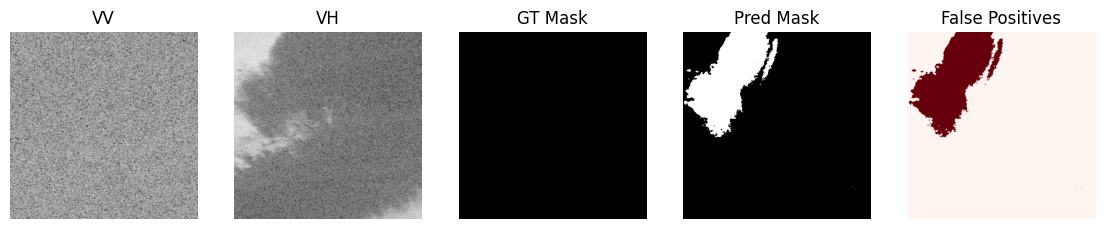

Image 0:
  IoU: 0.0000
  F1 : 0.0000
  FAR: 0.1368
  ECE: 0.1453


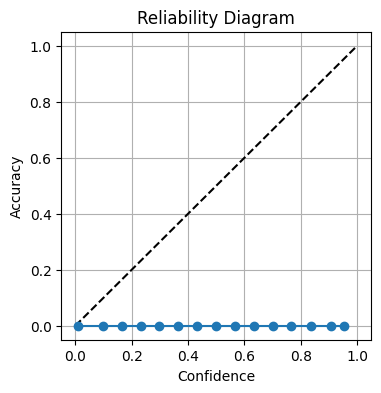

In [18]:
# Choose which test item to inspect
#val_items = [test_no_oil_items[53]]
val_items = test_look_items
# No cropping, no augmentation for qualitative inspection
val_ds = OilSpillDataset(val_items, crop_size=None, augment=False)

from torch.utils.data import DataLoader

model.eval()  # important: eval mode
with torch.no_grad():  # no gradients during evaluation
    for x, y in DataLoader(val_ds, batch_size=1, shuffle=False):
        x = x.to(device); y = y.to(device)
        out = model(x)['out']          # logits
        viz_batch_metrics(x, y, out, thr=0.3, show_metrics=True)
        break  # only one image in this dataset


# 9. Optional Fine-Tuning

> **Optional section — do not run during ordinary inference.**

Fine-tuning continues training from an existing model checkpoint using
a lower learning rate.

Current fine-tuning configuration:

- Epochs: 15
- Learning rate: 1e-4
- Optimizer: AdamW
- Scheduler: Cosine Annealing

Fine-tuning should use the training/validation data only. The independent
holdout test set should remain untouched until final evaluation.

In [ ]:
from sklearn.model_selection import KFold
from torch.amp import GradScaler, autocast
import os, csv
from datetime import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# ------------------------------
# Fine-tune hyperparameters
# ------------------------------
FT_EPOCHS = 15          # how many fine-tune epochs per fold
FT_LR     = 1e-4        # smaller learning rate for fine-tuning

kfold = KFold(n_splits=cfg.k_folds, shuffle=True, random_state=cfg.seed)
fold_summaries = []

# VV+VH run
cfg.in_channels = 2

for fold, (train_idx, val_idx) in enumerate(kfold.split(all_items), start=5):
    print('='*80)
    print(f'📚 Fine-tune Fold {fold}/{cfg.k_folds}')
    print('='*80)

    # ---------------------------------
    # Build train / val datasets & loaders
    # ---------------------------------
    train_items = [all_items[i] for i in train_idx]
    val_items   = [all_items[i] for i in val_idx]

    train_ds = OilSpillDataset(train_items, crop_size=cfg.crop_size, augment=True)
    val_ds   = OilSpillDataset(val_items,   crop_size=cfg.crop_size, augment=False)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )
    val_loader   = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # ---------------------------------
    # Checkpoints
    # ---------------------------------
    # Original best (from previous training run)
    ckpt_path        = os.path.join(cfg.out_dir, f'unet_densenet201_new_oil_{fold}_ft_best.pt')
    # New fine-tuned best (by val IoU)
    ft_ckpt_path     = os.path.join(cfg.out_dir, f'unet_densenet201_new_oil_fold{fold}_ft_best.pt')
    # New best by test IoU
    ft_ckpt_path_test = os.path.join(cfg.out_dir, f'unet_densenet201_new_oil_fold{fold}_ft_best_on_test.pt')
    ckpt_path        = ft_ckpt_path
    if not os.path.exists(ckpt_path):
        print(f"⚠️  No base checkpoint found for fold {fold}: {ckpt_path}. Skipping.")
        continue

    # ---------------------------------
    # Build model and load pre-trained weights
    # ---------------------------------
    model = build_model(cfg).to(device)

    print(f"🔁 Loading base checkpoint for fold {fold} from {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    state = ckpt.get('state_dict', ckpt)
    state = {k.replace('module.', ''): v for k, v in state.items()}
    model.load_state_dict(state, strict=True)

    prev_epoch   = ckpt.get('epoch', 0)
    prev_metrics = ckpt.get('metrics', {})

    # Start fine-tune from the previously best validation IoU
    best_val_iou     = prev_metrics.get('IoU', -1.0)
    best_val_metrics = prev_metrics
    best_test_iou    = -1.0   # we’ll track this only during FT

    print(f"  Base checkpoint: epoch={prev_epoch}, val IoU={best_val_iou:.4f}")

    # ---------------------------------
    # Optimizer & scheduler for FT
    # ---------------------------------
    opt = torch.optim.AdamW(model.parameters(), lr=FT_LR, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_EPOCHS)

    scaler = GradScaler('cuda', enabled=cfg.amp)

    # ---------------------------------
    # Fine-tune loop (FT_EPOCHS only)
    # ---------------------------------
    for ft_epoch in range(1, FT_EPOCHS + 1):
        global_epoch = prev_epoch + ft_epoch  # for logging

        # -------- TRAIN --------
        model.train()
        tr_loss = 0.0
        for x, y in tqdm(train_loader, desc=f'Fold {fold} FT Epoch {ft_epoch}/{FT_EPOCHS} [train]'):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=cfg.amp):
                out = model(x)['out']
                loss = loss_fn(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            tr_loss += loss.item() * x.size(0)

        tr_loss /= max(1, len(train_loader.dataset))
        sched.step()

        # -------- VALIDATION (fold val set) --------
        val_metrics = validate_with_calibration(
            model, val_loader, device, n_bins=cfg.n_bins, ignore_index=255
        )

        # -------- TEST SET EVAL (hold-out test_loader, NOT used for training) --------
        #test_metrics = validate_with_calibration(
        #    model, test_loader, device, n_bins=cfg.n_bins, ignore_index=255
        #)

        print(
            f"Fold {fold} FT-Epoch {ft_epoch:03d} (global {global_epoch}) | "
            f"train {tr_loss:.4f} | "
            f"val_loss {val_metrics['loss']:.4f} | "
            f"val_IoU {val_metrics['IoU']:.4f} | "
            f"val_F1 {val_metrics['F1']:.4f} | "
            f"FAR {val_metrics['FAR']:.4f} | "
            f"ECE {val_metrics['ECE']:.4f} | "
            f"U_var {val_metrics['uncertainty_var']:.4f} || "
            #f"test_IoU {test_metrics['IoU']:.4f} | "
            #f"test_F1 {test_metrics['F1']:.4f}"
        )

        # -------- LOG TO CSV --------
        with open(cfg.log_file, mode="a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                datetime.now().isoformat(timespec="seconds"),
                fold,
                global_epoch,              # log global epoch index
                f"{tr_loss:.4f}",
                f"{val_metrics['loss']:.4f}",
                f"{val_metrics['IoU']:.4f}",
                f"{val_metrics['F1']:.4f}",
                f"{val_metrics['FAR']:.4f}",
                f"{val_metrics['ECE']:.4f}",
                f"{val_metrics['uncertainty_var']:.4f}",
                #f"{test_metrics['IoU']:.4f}",
                #f"{test_metrics['F1']:.4f}",
            ])

        # -------- SAVE BEST BY VALIDATION IoU (including original best) --------
        if val_metrics['IoU'] > best_val_iou:
            best_val_iou     = val_metrics['IoU']
            best_val_metrics = val_metrics
            torch.save({
                'state_dict': model.state_dict(),
                'cfg': vars(cfg),
                'fold': fold,
                'epoch': global_epoch,
                'metrics': best_val_metrics
            }, ft_ckpt_path)
            print(f"  ✅ [VAL] New best fold {fold} IoU={best_val_iou:.4f} saved to {ft_ckpt_path}")

        # -------- SAVE BEST BY TEST IoU (separate file) --------
        '''if test_metrics['IoU'] > best_test_iou:
            best_test_iou = test_metrics['IoU']
            torch.save({
                'state_dict': model.state_dict(),
                'cfg': vars(cfg),
                'fold': fold,
                'epoch': global_epoch,
                'val_metrics': val_metrics,
                'test_metrics': test_metrics
            }, ft_ckpt_path_test)
            print(f"  ⭐ [TEST] New best fold {fold} test_IoU={best_test_iou:.4f} saved to {ft_ckpt_path_test}")
            '''
    # ---------------------------------
    # Store summary for this fold
    # ---------------------------------
    if best_val_metrics is None:
        best_val_metrics = {'IoU': 0.0, 'F1': 0.0, 'FAR': 0.0, 'ECE': 0.0, 'uncertainty_var': 0.0}

    fold_summaries.append({
        'fold': fold,
        'best_val_IoU':  best_val_metrics['IoU'],
        'best_val_F1':   best_val_metrics['F1'],
        'best_val_FAR':  best_val_metrics['FAR'],
        'best_val_ECE':  best_val_metrics['ECE'],
        'best_val_Uvar': best_val_metrics['uncertainty_var'],
        'best_test_IoU': best_test_iou,
    })

    print(
        f"Fold {fold} FINAL best VAL: IoU={best_val_metrics['IoU']:.4f}, "
        f"F1={best_val_metrics['F1']:.4f}, FAR={best_val_metrics['FAR']:.4f}, "
        f"ECE={best_val_metrics['ECE']:.4f}, Uvar={best_val_metrics['uncertainty_var']:.4f}"
    )
    print(f"Fold {fold} FINAL best TEST IoU: {best_test_iou:.4f}")


RUN this for multi run uncertainty variance (old)

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


# --- ADD: reliability plotting helper (minimal extra) ---
import matplotlib.pyplot as plt

def plot_reliability_from_bins(bin_conf, bin_acc, title="Reliability Diagram"):
    """
    Uses the returned bin_conf / bin_acc from evaluate_dataset_miou_f1_mc_dropout().
    """
    mask = ~np.isnan(bin_conf) & ~np.isnan(bin_acc)
    bc = bin_conf[mask]
    ba = bin_acc[mask]

    plt.figure(figsize=(4,4))
    plt.plot([0,1],[0,1],'k--',label='Perfect')
    plt.plot(bc, ba, marker='o', label='Model')
    plt.xlabel('Predicted confidence')
    plt.ylabel('Empirical accuracy')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

def _enable_dropout_only(model):
    """
    Enable dropout layers during inference (MC Dropout) while keeping BatchNorm in eval.
    Call model.eval() first, then this function.
    """
    dropout_types = (
        torch.nn.Dropout,
        torch.nn.Dropout2d,
        torch.nn.Dropout3d,
        torch.nn.AlphaDropout,
        torch.nn.FeatureAlphaDropout,
    )
    for m in model.modules():
        if isinstance(m, dropout_types):
            m.train()

def evaluate_dataset_miou_f1_mc_dropout(
    model,
    dataset,
    device,
    thr=0.3,
    batch_size=3,
    n_bins=10,
    ignore_index=None,
    mc_passes=20,                 # number of stochastic forward passes
    mc_unbiased_var=False,         # False => population var (divide by T), True => unbiased (T-1)
    plot_reliability=True,        # --- ADD: plot at the end (minimal change)
    reliability_title="Reliability Diagram (MC Dropout mean probs)"  # --- ADD
):
    """
    Computes:
      - mIoU, mF1, FAR, ECE (same behavior as your original, but using mean probs across MC passes)
      - mc_uncertainty_var: mean pixel-wise variance of P(oil) across MC passes (epistemic)
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Keep BatchNorm, etc. in eval mode
    model.eval()

    # Turn ON dropout only (MC Dropout)
    if mc_passes and mc_passes > 1:
        _enable_dropout_only(model)

    all_iou = []
    all_f1  = []

    TP = FP = TN = FN = 0
    total_px = 0

    bin_total    = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_correct  = np.zeros(n_bins, dtype=np.float64)

    # MC variance accumulator
    mc_var_sum = 0.0  # sum of per-pixel var(P(oil))
    mc_var_px  = 0    # count of valid pixels included

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            if y.ndim == 4:
                y = y.squeeze(1)  # (B,H,W)

            # --- MC Dropout: compute mean probs and var probs (P(oil)) across passes ---
            if mc_passes and mc_passes > 1:
                # Welford online mean/variance for probs (B,H,W)
                mean = None
                M2   = None
                for t in range(mc_passes):
                    logits_t = model(x)['out']                 # (B,2,H,W)
                    probs_t  = F.softmax(logits_t, dim=1)[:,1] # (B,H,W) P(oil)

                    if mean is None:
                        mean = probs_t.clone()
                        M2   = torch.zeros_like(probs_t)
                    else:
                        delta = probs_t - mean
                        mean = mean + delta / (t + 1)
                        delta2 = probs_t - mean
                        M2 = M2 + delta * delta2

                probs = mean  # mean P(oil) used for preds + metrics

                if mc_passes > 1:
                    denom = (mc_passes - 1) if mc_unbiased_var else mc_passes
                    var_map = M2 / max(1, denom)  # (B,H,W) variance of P(oil)
                else:
                    var_map = torch.zeros_like(probs)

            else:
                # single pass fallback (no MC)
                logits = model(x)['out']
                probs  = F.softmax(logits, dim=1)[:,1]
                var_map = torch.zeros_like(probs)

            preds = (probs > thr).long()

            # Move to CPU numpy for IoU/F1, bins (keep same structure as yours)
            y_np     = y.detach().cpu().numpy()
            preds_np = preds.detach().cpu().numpy()
            probs_np = probs.detach().cpu().numpy()
            var_np   = var_map.detach().cpu().numpy()

            # ----- per-image IoU/F1 -----
            for i in range(preds_np.shape[0]):
                iou, f1 = compute_iou_f1(y_np[i], preds_np[i])  # assumes your function exists
                all_iou.append(iou)
                all_f1.append(f1)

            # ----- global calibration + FAR stats -----
            p_flat  = probs_np.ravel()   # mean P(oil)
            y_flat  = y_np.ravel()
            pr_flat = preds_np.ravel()   # predicted class 0/1
            v_flat  = var_np.ravel()     # var(P(oil))

            if ignore_index is not None:
                valid = (y_flat != ignore_index)
                p_flat  = p_flat[valid]
                y_flat  = y_flat[valid]
                pr_flat = pr_flat[valid]
                v_flat  = v_flat[valid]

            if p_flat.size == 0:
                continue

            # Confidence of the predicted class (same as your logic)
            conf_flat = np.where(pr_flat == 1, p_flat, 1.0 - p_flat)

            total_px += conf_flat.size

            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            # Reliability bins (same as your logic)
            bin_idx = np.minimum((conf_flat * n_bins).astype(int), n_bins - 1)
            for b in range(n_bins):
                m = (bin_idx == b)
                if not np.any(m):
                    continue
                bin_total[b]    += m.sum()
                bin_conf_sum[b] += conf_flat[m].sum()
                bin_correct[b]  += np.sum(pr_flat[m] == y_flat[m])

            # ----- MC uncertainty: variance of P(oil) across passes -----
            # This is the "true multi-inference variance" (epistemic proxy).
            mc_var_sum += float(np.sum(v_flat))
            mc_var_px  += int(v_flat.size)

    miou = float(np.mean(all_iou)) if all_iou else 0.0
    mf1  = float(np.mean(all_f1))  if all_f1 else 0.0
    FAR  = FP / max(1, (FP + TN))

    # ECE from bins (same as your logic)
    ece = 0.0
    bin_acc  = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    if total_px > 0:
        for b in range(n_bins):
            if bin_total[b] == 0:
                bin_acc[b]  = np.nan
                bin_conf[b] = np.nan
                continue
            bin_acc[b]  = bin_correct[b] / bin_total[b]
            bin_conf[b] = bin_conf_sum[b] / bin_total[b]
            weight = bin_total[b] / total_px
            ece += weight * abs(bin_acc[b] - bin_conf[b])

    mc_uncertainty_var = mc_var_sum / max(1, mc_var_px)

    print(f"mIoU over {len(all_iou)} images: {miou:.4f}")
    print(f"mF1  over {len(all_f1)} images: {mf1:.4f}")
    print(f"FAR  over all pixels       : {FAR:.4f}")
    print(f"ECE                        : {ece:.4f}")
    print(f"MC Dropout var P(oil)      : {mc_uncertainty_var:.6f}  (passes={mc_passes})")

    # --- ADD: plot reliability diagram using the same bins ---
    if plot_reliability:
        plot_reliability_from_bins(bin_conf, bin_acc, title=reliability_title)

    return {
        "mIoU": miou,
        "mF1": mf1,
        "FAR": float(FAR),
        "ECE": float(ece),
        "mc_uncertainty_var": float(mc_uncertainty_var),
        "TP": int(TP),
        "FP": int(FP),
        "TN": int(TN),
        "FN": int(FN),
        "bin_conf": bin_conf,
        "bin_acc": bin_acc,
        "bin_total": bin_total,
    }


# 10. Calibration and MC Dropout Uncertainty

This section evaluates model calibration and epistemic uncertainty.

### Threshold-dependent metrics

The following depend on the selected oil probability threshold:

- IoU
- F1-score
- False Alarm Rate

### Threshold-free calibration

The reliability diagram compares:

- **x-axis:** Mean predicted probability of oil
- **y-axis:** Observed fraction of oil pixels

The Expected Calibration Error (ECE) summarizes the discrepancy between
these quantities.

### Monte Carlo Dropout

When `mc_passes > 1`, dropout remains active during inference and the
image is evaluated multiple times.

The variance of `P(oil)` across the stochastic predictions is used as
an estimate of epistemic uncertainty.

When:

`mc_passes = 0`

the model performs normal deterministic inference and the MC Dropout
variance is zero.

In [19]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

def plot_reliability_from_bins_prob(bin_conf, bin_acc, title="Reliability Diagram (threshold-free)"):
    """
    Threshold-free reliability:
      x = mean predicted P(oil) in bin
      y = empirical fraction of oil pixels in bin
    """
    mask = ~np.isnan(bin_conf) & ~np.isnan(bin_acc)
    bc = bin_conf[mask]
    ba = bin_acc[mask]

    plt.figure(figsize=(4,4))
    plt.plot([0,1],[0,1],'k--',label='Perfect')
    plt.plot(bc, ba, marker='o', label='Model')
    plt.xlabel('Predicted probability')
    plt.ylabel('Observed frequency')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def _enable_dropout_only(model):
    dropout_types = (
        torch.nn.Dropout,
        torch.nn.Dropout2d,
        torch.nn.Dropout3d,
        torch.nn.AlphaDropout,
        torch.nn.FeatureAlphaDropout,
    )
    for m in model.modules():
        if isinstance(m, dropout_types):
            m.train()


def evaluate_dataset_miou_f1_mc_dropout(
    model,
    dataset,
    device,
    thr=0.3,
    batch_size=3,
    n_bins=10,
    ignore_index=None,
    mc_passes=20,
    mc_unbiased_var=False,
    plot_reliability=True,
    reliability_title="Reliability Diagram (P(oil), threshold-free)"
):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    if mc_passes and mc_passes > 1:
        _enable_dropout_only(model)

    all_iou = []
    all_f1  = []

    TP = FP = TN = FN = 0

    # --- Threshold-free calibration accumulators ---
    total_px = 0
    bin_total    = np.zeros(n_bins, dtype=np.float64)
    bin_conf_sum = np.zeros(n_bins, dtype=np.float64)
    bin_pos_sum  = np.zeros(n_bins, dtype=np.float64)   # sum of y (positives) per bin

    # MC variance accumulator
    mc_var_sum = 0.0
    mc_var_px  = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            if y.ndim == 4:
                y = y.squeeze(1)

            # --- MC Dropout mean probs + var probs ---
            if mc_passes and mc_passes > 1:
                mean = None
                M2   = None
                for t in range(mc_passes):
                    logits_t = model(x)['out']
                    probs_t  = F.softmax(logits_t, dim=1)[:,1]  # P(oil)

                    if mean is None:
                        mean = probs_t.clone()
                        M2   = torch.zeros_like(probs_t)
                    else:
                        delta = probs_t - mean
                        mean = mean + delta / (t + 1)
                        delta2 = probs_t - mean
                        M2 = M2 + delta * delta2

                probs = mean
                denom = (mc_passes - 1) if mc_unbiased_var else mc_passes
                var_map = M2 / max(1, denom)
            else:
                logits = model(x)['out']
                probs  = F.softmax(logits, dim=1)[:,1]
                var_map = torch.zeros_like(probs)

            # --- Thresholded preds for IoU/F1/FAR (still uses thr) ---
            preds = (probs > thr).long()

            y_np     = y.detach().cpu().numpy()
            preds_np = preds.detach().cpu().numpy()
            probs_np = probs.detach().cpu().numpy()
            var_np   = var_map.detach().cpu().numpy()

            # per-image IoU/F1
            for i in range(preds_np.shape[0]):
                iou, f1 = compute_iou_f1(y_np[i], preds_np[i])  # your existing helper
                all_iou.append(iou)
                all_f1.append(f1)

            # flatten
            p_flat  = probs_np.ravel()   # P(oil)  <-- threshold-free calibration uses this
            y_flat  = y_np.ravel()
            pr_flat = preds_np.ravel()   # for FAR/confusion (thresholded)
            v_flat  = var_np.ravel()

            if ignore_index is not None:
                valid = (y_flat != ignore_index)
                p_flat  = p_flat[valid]
                y_flat  = y_flat[valid]
                pr_flat = pr_flat[valid]
                v_flat  = v_flat[valid]

            if p_flat.size == 0:
                continue

            # --- confusion for FAR etc (depends on thr) ---
            TP += np.sum((pr_flat == 1) & (y_flat == 1))
            FP += np.sum((pr_flat == 1) & (y_flat == 0))
            TN += np.sum((pr_flat == 0) & (y_flat == 0))
            FN += np.sum((pr_flat == 0) & (y_flat == 1))

            # --- Threshold-free reliability bins: bin by P(oil) ---
            total_px += p_flat.size
            bin_idx = np.minimum((p_flat * n_bins).astype(int), n_bins - 1)
            for b in range(n_bins):
                m = (bin_idx == b)
                if not np.any(m):
                    continue
                bin_total[b]    += m.sum()
                bin_conf_sum[b] += p_flat[m].sum()
                bin_pos_sum[b]  += y_flat[m].sum()   # empirical positives

            # MC uncertainty var sum
            mc_var_sum += float(np.sum(v_flat))
            mc_var_px  += int(v_flat.size)

    miou = float(np.mean(all_iou)) if all_iou else 0.0
    mf1  = float(np.mean(all_f1))  if all_f1 else 0.0
    FAR  = FP / max(1, (FP + TN))

    # --- Threshold-free ECE + bin curves ---
    ece = 0.0
    bin_acc  = np.zeros(n_bins, dtype=np.float64)
    bin_conf = np.zeros(n_bins, dtype=np.float64)
    if total_px > 0:
        for b in range(n_bins):
            if bin_total[b] == 0:
                bin_acc[b]  = np.nan
                bin_conf[b] = np.nan
                continue
            bin_conf[b] = bin_conf_sum[b] / bin_total[b]   # mean predicted P(oil)
            bin_acc[b]  = bin_pos_sum[b]  / bin_total[b]   # empirical P(oil)
            weight = bin_total[b] / total_px
            ece += weight * abs(bin_acc[b] - bin_conf[b])

    mc_uncertainty_var = mc_var_sum / max(1, mc_var_px)

    print(f"mIoU over {len(all_iou)} images: {miou:.4f}")
    print(f"mF1  over {len(all_f1)} images: {mf1:.4f}")
    print(f"FAR  over all pixels       : {FAR:.4f}   (depends on thr={thr})")
    print(f"ECE (threshold-free, P(oil)): {ece:.4f}")
    print(f"MC Dropout var P(oil)      : {mc_uncertainty_var:.6f}  (passes={mc_passes})")

    if plot_reliability:
        plot_reliability_from_bins_prob(bin_conf, bin_acc, title=reliability_title)

    return {
        "mIoU": miou,
        "mF1": mf1,
        "FAR": float(FAR),
        "ECE": float(ece),  # now threshold-free
        "mc_uncertainty_var": float(mc_uncertainty_var),
        "TP": int(TP),
        "FP": int(FP),
        "TN": int(TN),
        "FN": int(FN),
        "bin_conf": bin_conf,  # threshold-free bins (mean P(oil))
        "bin_acc": bin_acc,    # threshold-free bins (empirical P(oil))
        "bin_total": bin_total,
    }


# 11. Look-Alike False Positive Analysis

A major challenge in SAR-based oil spill detection is distinguishing
actual oil spills from look-alike phenomena.

This section evaluates how frequently look-alike test images are
incorrectly identified as oil.

Two complementary false-positive measurements are reported.

### Image-Level False Detection Rate

Percentage of look-alike scenes containing at least the specified
number of falsely detected oil pixels.

### Pixel-Level False Positive Rate

Percentage of background pixels across the complete look-alike dataset
that are incorrectly classified as oil.

### Visual Inspection

Selected false-positive cases are displayed using:

- VV image
- VH image
- Predicted oil probability
- Predicted oil mask
- False-positive mask

This analysis helps determine whether a model with good segmentation
metrics also remains robust against oil-spill look-alikes.




In [20]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


def evaluate_lookalike_false_positives(
    model,
    dataset,
    device,
    thr=0.3,
    ignore_index=255,
    show_images=True,
    max_show=10,
    min_fp_pixels=1
):
    """
    Evaluate false-positive oil detections on look-alike images.

    Reports:
      1. Number / percentage of look-alike images with false oil detection
      2. Total false-positive pixels
      3. Overall false-positive pixel percentage
      4. Mean false-positive pixel percentage per image

    min_fp_pixels:
        Minimum number of false-positive pixels required to count an image
        as a false-positive detection.
        Default = 1 pixel.
    """

    loader = DataLoader(
        dataset,
        batch_size=1,      # full images may have different dimensions
        shuffle=False
    )

    model.eval()

    total_images = 0
    images_with_fp = 0

    total_fp_pixels = 0
    total_background_pixels = 0
    total_gt_oil_pixels = 0

    per_image_results = []

    shown = 0

    with torch.no_grad():

        for idx, (x, y) in enumerate(loader):

            x = x.to(device)
            y = y.to(device)

            if y.ndim == 4:
                y = y.squeeze(1)

            # ---------------------------
            # Model inference
            # ---------------------------
            logits = model(x)['out']

            # probability of oil
            probs = F.softmax(logits, dim=1)[:, 1]

            # predicted oil using chosen threshold
            preds = (probs > thr).long()

            # ---------------------------
            # Convert first/only image
            # ---------------------------
            y_i = y[0]
            pred_i = preds[0]
            prob_i = probs[0]

            # valid pixels
            if ignore_index is not None:
                valid = (y_i != ignore_index)
            else:
                valid = torch.ones_like(y_i, dtype=torch.bool)

            # ---------------------------
            # False positives
            # ---------------------------
            fp_mask = (
                (pred_i == 1) &
                (y_i == 0) &
                valid
            )

            background_mask = (
                (y_i == 0) &
                valid
            )

            gt_oil_mask = (
                (y_i == 1) &
                valid
            )

            fp_pixels = fp_mask.sum().item()
            background_pixels = background_mask.sum().item()
            gt_oil_pixels = gt_oil_mask.sum().item()

            total_images += 1
            total_fp_pixels += fp_pixels
            total_background_pixels += background_pixels
            total_gt_oil_pixels += gt_oil_pixels

            # Image considered falsely detected as oil
            detected = fp_pixels >= min_fp_pixels

            if detected:
                images_with_fp += 1

            # Percentage of this image incorrectly marked as oil
            fp_pixel_percent = (
                100.0 * fp_pixels / max(1, background_pixels)
            )

            # Get filename if available
            if hasattr(dataset, "items"):
                item_name = dataset.items[idx].get(
                    "name",
                    f"image_{idx}"
                )
            else:
                item_name = f"image_{idx}"

            per_image_results.append({
                "image": item_name,
                "fp_pixels": fp_pixels,
                "background_pixels": background_pixels,
                "fp_pixel_percent": fp_pixel_percent,
                "detected_as_oil": detected
            })

            # ---------------------------
            # Show false-positive examples
            # ---------------------------
            if show_images and detected and shown < max_show:

                x_np = x[0].detach().cpu().numpy()
                y_np = y_i.detach().cpu().numpy()
                pred_np = pred_i.detach().cpu().numpy()
                prob_np = prob_i.detach().cpu().numpy()
                fp_np = fp_mask.detach().cpu().numpy()

                vv = x_np[0]
                vh = x_np[1]

                # Normalize only for visualization
                vv_show = (
                    (vv - vv.min()) /
                    (vv.max() - vv.min() + 1e-6)
                )

                vh_show = (
                    (vh - vh.min()) /
                    (vh.max() - vh.min() + 1e-6)
                )

                plt.figure(figsize=(15, 4))

                plt.subplot(1, 5, 1)
                plt.imshow(vv_show, cmap="gray")
                plt.title("VV")
                plt.axis("off")

                plt.subplot(1, 5, 2)
                plt.imshow(vh_show, cmap="gray")
                plt.title("VH")
                plt.axis("off")

                plt.subplot(1, 5, 3)
                plt.imshow(prob_np, cmap="viridis", vmin=0, vmax=1)
                plt.title("P(Oil)")
                plt.axis("off")

                plt.subplot(1, 5, 4)
                plt.imshow(pred_np, cmap="gray")
                plt.title(f"Predicted Oil\nthr={thr}")
                plt.axis("off")

                plt.subplot(1, 5, 5)
                plt.imshow(fp_np, cmap="Reds")
                plt.title(
                    f"False Positives\n"
                    f"{fp_pixel_percent:.3f}%"
                )
                plt.axis("off")

                plt.suptitle(item_name)
                plt.tight_layout()
                plt.show()

                shown += 1


    # ==========================================================
    # Overall results
    # ==========================================================

    image_fp_rate = (
        100.0 * images_with_fp / max(1, total_images)
    )

    overall_fp_pixel_rate = (
        100.0 * total_fp_pixels /
        max(1, total_background_pixels)
    )

    mean_fp_percent = (
        np.mean([
            r["fp_pixel_percent"]
            for r in per_image_results
        ])
        if per_image_results else 0.0
    )


    print("=" * 65)
    print("LOOK-ALIKE FALSE POSITIVE ANALYSIS")
    print("=" * 65)

    print(f"Threshold                     : {thr}")
    print(f"Total look-alike images       : {total_images}")

    print(
        f"Images with false oil detection: "
        f"{images_with_fp}/{total_images}"
    )

    print(
        f"Image-level FP detection rate : "
        f"{image_fp_rate:.2f}%"
    )

    print()

    print(f"Total background pixels       : {total_background_pixels:,}")
    print(f"False-positive oil pixels     : {total_fp_pixels:,}")

    print(
        f"Overall FP pixel rate         : "
        f"{overall_fp_pixel_rate:.4f}%"
    )

    print(
        f"Mean FP pixels per image (%)  : "
        f"{mean_fp_percent:.4f}%"
    )

    print()

    print(
        f"Ground-truth oil pixels found : "
        f"{total_gt_oil_pixels:,}"
    )

    if total_gt_oil_pixels == 0:
        print(
            "✓ Confirmed: look-alike ground-truth masks "
            "contain no oil pixels."
        )
    else:
        print(
            "⚠ WARNING: some ground-truth oil pixels were found."
        )

    print("=" * 65)

    return {
        "total_images": total_images,
        "images_with_fp": images_with_fp,
        "image_fp_rate_percent": image_fp_rate,

        "total_background_pixels": total_background_pixels,
        "total_fp_pixels": total_fp_pixels,
        "overall_fp_pixel_rate_percent": overall_fp_pixel_rate,

        "mean_fp_pixel_percent_per_image": mean_fp_percent,

        "ground_truth_oil_pixels": total_gt_oil_pixels,

        "per_image": per_image_results
    }

# 12. Experiment Summary

Record the final results used in the thesis or publication in this section.

Recommended results to report:

| Test Set | mIoU | F1 | FAR | ECE | MC Variance |
|---|---:|---:|---:|---:|---:|
| Oil | — | — | — | — | — |
| No Oil | — | — | — | — | — |
| Look-Alike | — | — | — | — | — |
| Combined | — | — | — | — | — |

Also record:

- Model checkpoint
- Probability threshold
- Number of MC Dropout passes
- Number of test images
- Image-level look-alike false detection rate
- Pixel-level look-alike false-positive rate

In [21]:
# ============================================================
# LOAD INDEPENDENT HOLDOUT TEST SET
# Run this ONLY during final inference / evaluation
# ============================================================

def build_holdout_test_items(cfg: Cfg) -> List[Dict]:
    """
    Load the independent holdout test dataset.

    IMPORTANT:
        This function should only be called during final inference
        and evaluation.

        These images are NOT included in K-fold training or validation.
    """

    items = []

    def add_test_pairs(img_subdir, mask_subdir, label):
        img_dir = os.path.join(cfg.data_dir, img_subdir)
        mask_dir = os.path.join(cfg.data_dir, mask_subdir)

        assert os.path.isdir(img_dir), f"Missing folder: {img_dir}"
        assert os.path.isdir(mask_dir), f"Missing folder: {mask_dir}"

        for name in sorted(os.listdir(img_dir)):
            if not name.lower().endswith('.tif'):
                continue

            img_path = os.path.join(img_dir, name)

            base = os.path.splitext(name)[0]

            # Your holdout masks use:
            # image_name.tif
            # image_name_segmentation.png/tif
            mask_base = base + '_segmentation'

            mask_png = os.path.join(mask_dir, mask_base + '.png')
            mask_tif = os.path.join(mask_dir, mask_base + '.tif')

            if os.path.exists(mask_png):
                mask_path = mask_png
            elif os.path.exists(mask_tif):
                mask_path = mask_tif
            else:
                print(f"[WARN] No holdout mask found for {img_path}")
                continue

            items.append({
                'img': img_path,
                'mask': mask_path,
                'subset': label,
                'name': name,
            })

    # Independent holdout data
    add_test_pairs(
        cfg.test_oil_img_dir,
        cfg.test_oil_mask_dir,
        'test_oil'
    )

    add_test_pairs(
        cfg.test_no_oil_img_dir,
        cfg.test_no_oil_mask_dir,
        'test_no_oil'
    )

    add_test_pairs(
        cfg.test_look_img_dir,
        cfg.test_look_mask_dir,
        'test_look'
    )

    return items

In [22]:
holdout_items = build_holdout_test_items(cfg)

holdout_oil_items = [
    i for i in holdout_items
    if i['subset'] == 'test_oil'
]

holdout_no_oil_items = [
    i for i in holdout_items
    if i['subset'] == 'test_no_oil'
]

holdout_look_items = [
    i for i in holdout_items
    if i['subset'] == 'test_look'
]


print("=" * 60)
print("INDEPENDENT HOLDOUT TEST SET")
print("=" * 60)
print(f"Oil       : {len(holdout_oil_items)}")
print(f"No oil    : {len(holdout_no_oil_items)}")
print(f"Lookalike : {len(holdout_look_items)}")
print(f"TOTAL     : {len(holdout_items)}")
print("=" * 60)

INDEPENDENT HOLDOUT TEST SET
Oil       : 150
No oil    : 150
Lookalike : 150
TOTAL     : 450


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

mIoU over 150 images: 0.6438
mF1  over 150 images: 0.7433
FAR  over all pixels       : 0.0097   (depends on thr=0.3)
ECE (threshold-free, P(oil)): 0.0479
MC Dropout var P(oil)      : 0.000000  (passes=0)


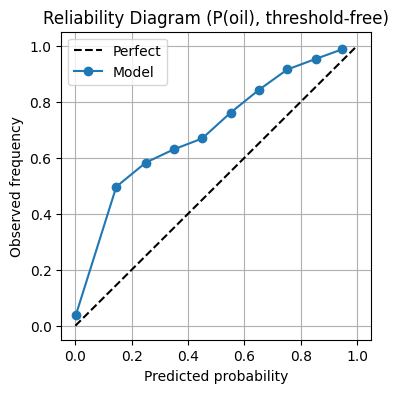

0.6437703899039384 0.009707579638773762 0.04789772906540787


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


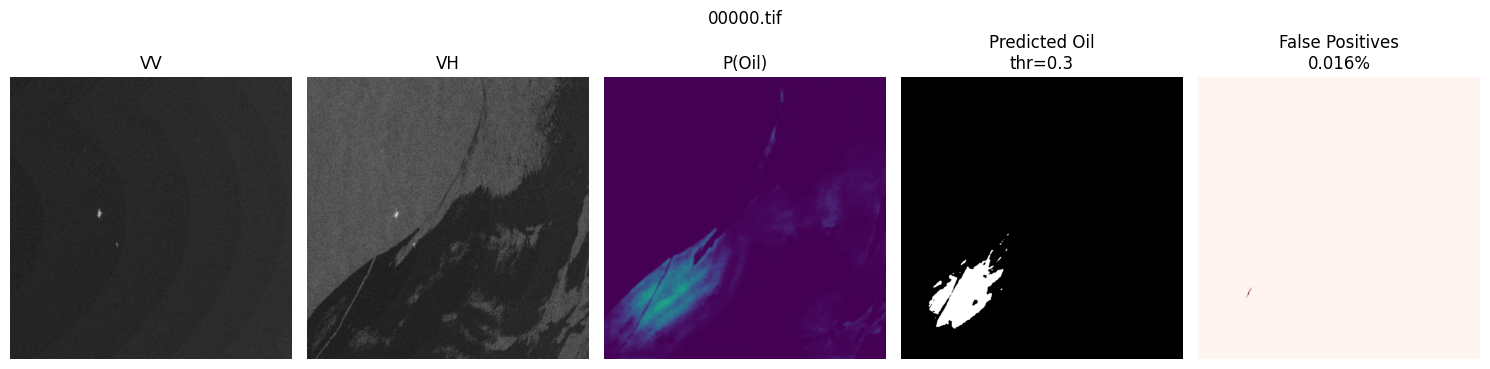

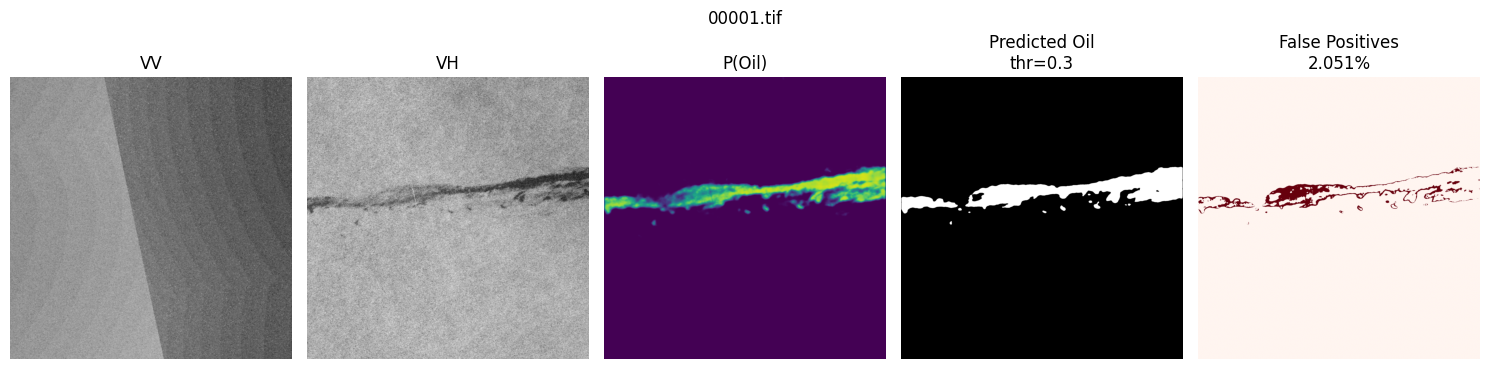

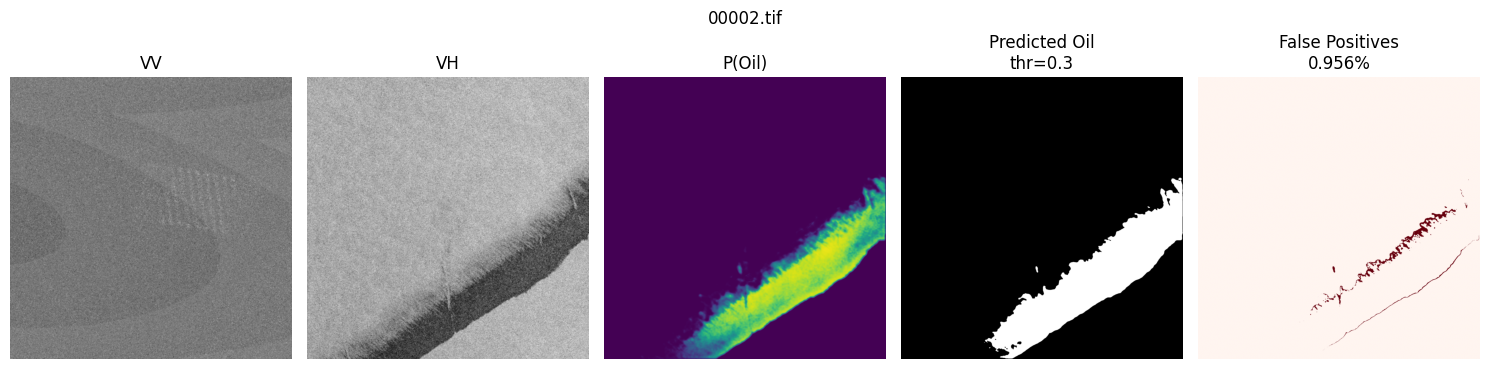

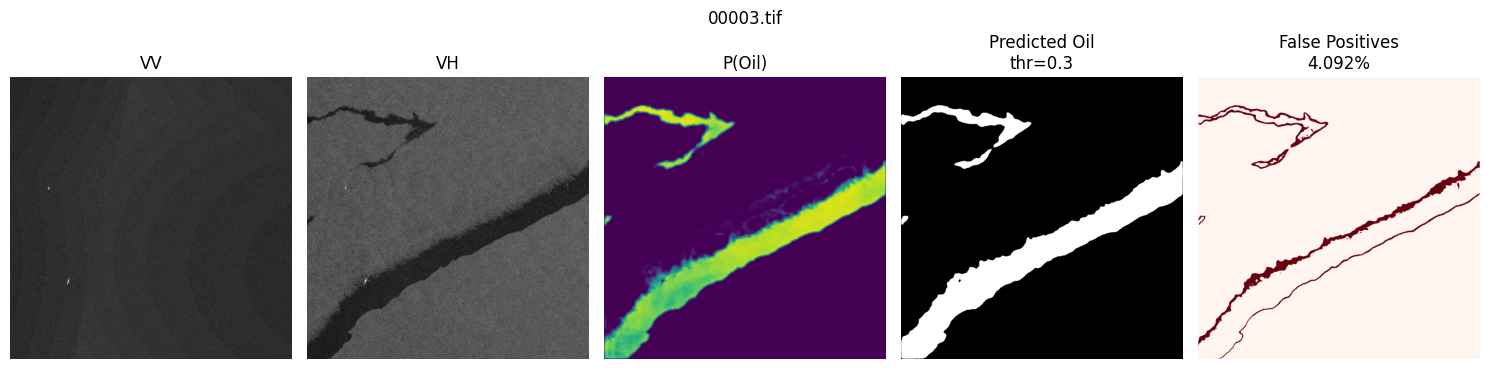

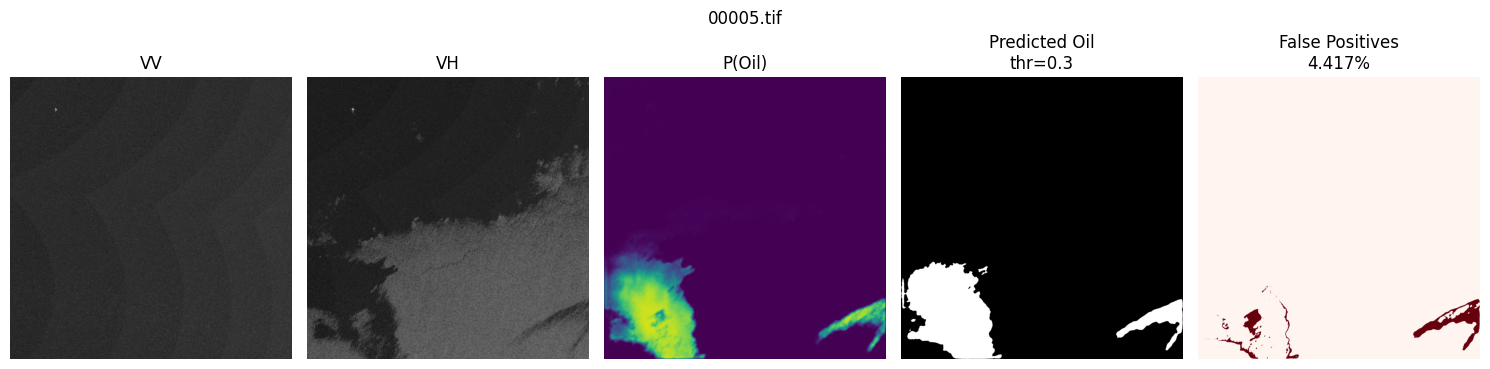

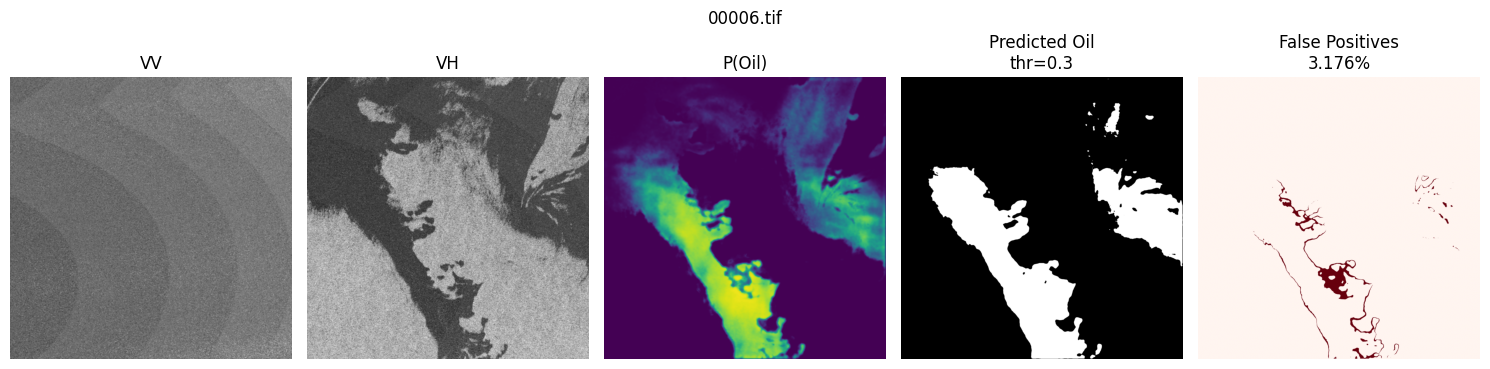

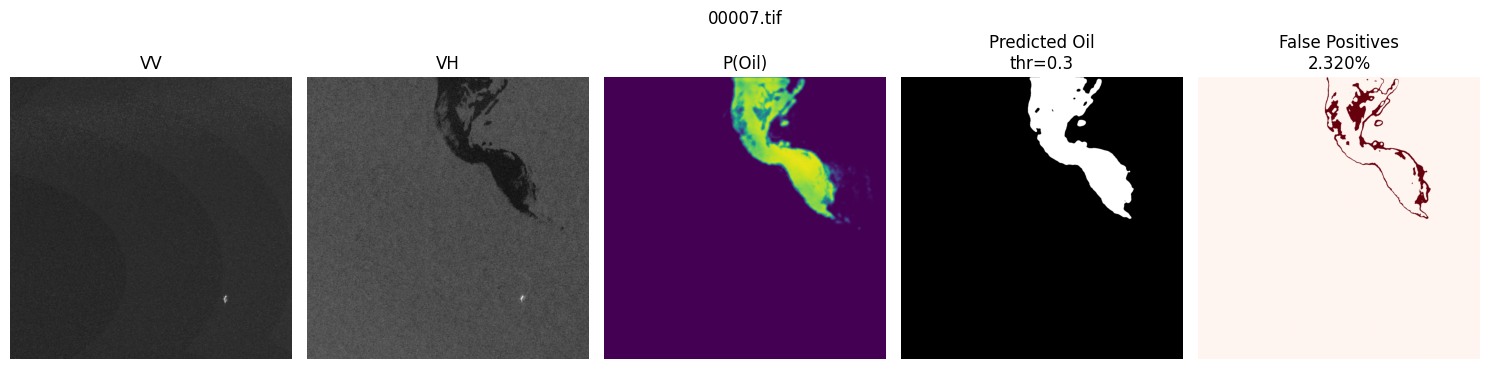

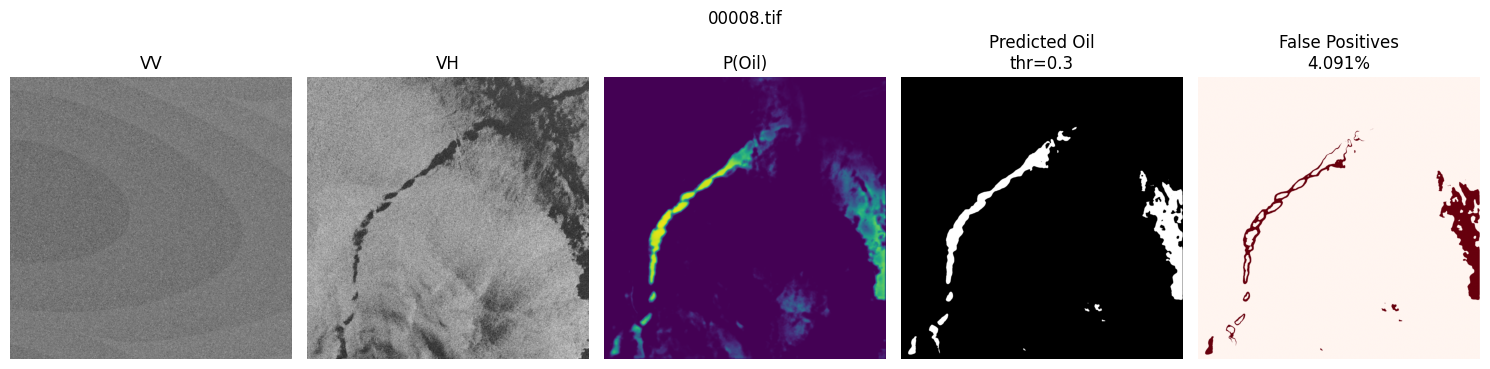

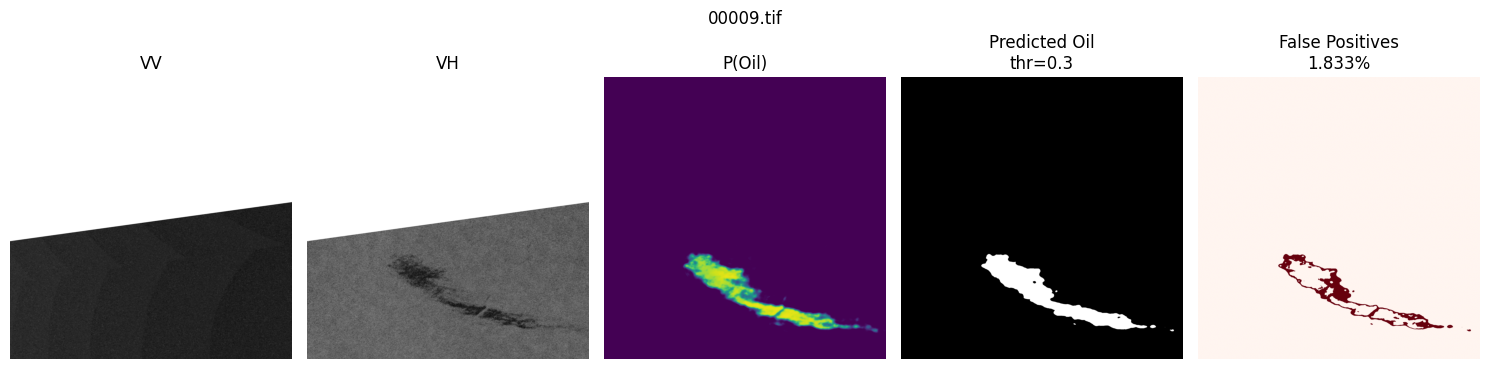

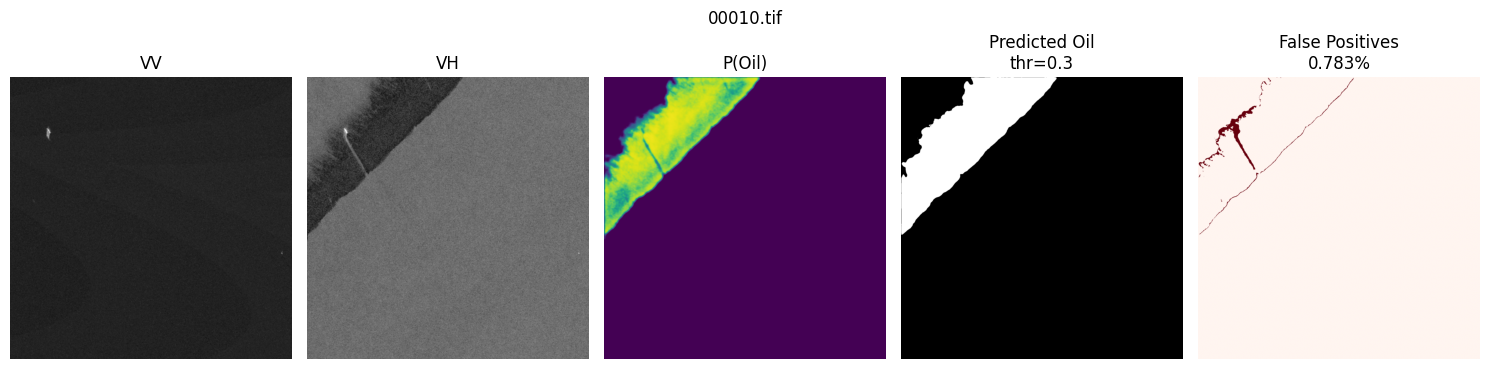

LOOK-ALIKE FALSE POSITIVE ANALYSIS
Threshold                     : 0.3
Total look-alike images       : 150
Images with false oil detection: 143/150
Image-level FP detection rate : 95.33%

Total background pixels       : 566,643,613
False-positive oil pixels     : 5,500,738
Overall FP pixel rate         : 0.9708%
Mean FP pixels per image (%)  : 1.0363%

Ground-truth oil pixels found : 62,501,987
⚠ WARNING: some ground-truth oil pixels were found.


In [23]:
# all test oil scenes you prepared earlier
val_items = holdout_oil_items         # NOT just one index now
#val_items = holdout_oil_items + holdout_no_oil_items + holdout_look_items

test_ds = OilSpillDataset(
    val_items,
    crop_size=None,   # full tiles for evaluation
    augment=False
)

stats_test = evaluate_dataset_miou_f1_mc_dropout(
#stats_test = evaluate_dataset_miou_f1(
    model,
    test_ds,
    device,
    thr=0.3,
    batch_size=1,
    n_bins=10,
    ignore_index=255,
    mc_passes=0,                 # number of stochastic forward passes
    mc_unbiased_var=False         # False => population var (divide by T), True => unbiased (T-1)
)

print(stats_test["mIoU"], stats_test["FAR"], stats_test["ECE"])

# ============================================================
# ADD: Look-alike false-positive analysis
# ============================================================

look_fp_stats = evaluate_lookalike_false_positives(
    model,
    test_ds,
    device,
    thr=0.3,
    ignore_index=255,

    show_images=True,    # show examples
    max_show=10,         # show first 10 images with FP

    min_fp_pixels=1
)
